## (0) Settings and Functions

In [1]:
%load_ext autotime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    KFold, RepeatedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    make_scorer, accuracy_score, f1_score, precision_score,
    recall_score, hamming_loss
)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

from imblearn.over_sampling import SMOTE
from collections import Counter

import warnings
from sklearn.exceptions import UndefinedMetricWarning

from scipy.sparse import hstack

warnings.filterwarnings(
    "ignore",
    category=UndefinedMetricWarning
)

time: 2.55 s (started: 2026-02-18 21:51:26 -03:00)


In [2]:
df = pd.read_csv("../../data/feat/go_emotions_with_features.csv")

print(df.shape)
df.head(3)

(54234, 56)


,UNCLEAN_TEXT_PT,BASE_TEXT_PT,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,punctuation_per_word,exclamation_per_word,question_per_word,mean_verbs_per_word,mean_auxiliaries_per_word,mean_auxiliaries_per_sentence,flesch_portuguese,uppercase_percentage,mean_unique_word_length,mean_char_repetition_per_word
0,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...,0,0,0,0,1,0,0,0,...,0.142857,0.0,0.0,0.095238,0.047619,0.5,77.937143,0.073684,4.388889,0.0
1,Você estragou isso. Eles tocaram você como um ...,voce estragou isso eles tocaram voce como violino,0,0,0,0,0,0,0,0,...,0.222222,0.0,0.0,0.222222,0.000000,0.0,61.320000,0.045455,4.833333,0.0
2,TL;DR Não há mais Super Bowls para [NAME]. Pre...,nao mais super bowls para name prepare-se para...,0,0,0,0,0,0,0,0,...,0.333333,0.0,0.0,0.125000,0.062500,0.5,72.640000,0.134831,4.666667,0.0


time: 839 ms (started: 2026-02-18 21:51:28 -03:00)


In [3]:
numerical_features = [
    'letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 
    'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word',
    'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 
    'uppercase_percentage', 'mean_unique_word_length', 'mean_char_repetition_per_word'
]

def evaluate_cv_smote_per_label(base_model, X_text, y, emotion_cols, n_splits=5, n_repeats=6, random_state=42):
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)

    metrics = {
        "accuracy": [],
        "precision_macro": [],
        "recall_macro": [],
        "f1_macro": [],
        "f1_weighted": [],
        "f1_micro": [],
    }

    for label_idx, label_name in enumerate(emotion_cols):
        print(f" → Label: {label_name}")

        y_label = y[:, label_idx]

        for train_idx, test_idx in rkf.split(X_text):
            X_train, X_test = X_text.iloc[train_idx], X_text.iloc[test_idx]
            y_train, y_test = y_label[train_idx], y_label[test_idx]

            X_train_text = X_train['BASE_TEXT_PT']
            X_test_text  = X_test['BASE_TEXT_PT']

            X_train_num = X_train[numerical_features].values
            X_test_num  = X_test[numerical_features].values

            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train_num)
            X_test_num  = scaler.transform(X_test_num)

            vectorizer = TfidfVectorizer()
            X_train_text_vec = vectorizer.fit_transform(X_train_text)
            X_test_text_vec  = vectorizer.transform(X_test_text)

            X_train_vec = hstack([X_train_text_vec, X_train_num])
            X_test_vec  = hstack([X_test_text_vec, X_test_num])

            if len(np.unique(y_train)) > 1:
                smote = SMOTE(random_state=random_state)
                X_train_vec, y_train = smote.fit_resample(
                    X_train_vec, y_train
                )

            clf = clone(base_model)
            clf.fit(X_train_vec, y_train)

            y_pred = clf.predict(X_test_vec)

            metrics["accuracy"].append(
                accuracy_score(y_test, y_pred)
            )
            metrics["precision_macro"].append(
                precision_score(y_test, y_pred, zero_division=0)
            )
            metrics["recall_macro"].append(
                recall_score(y_test, y_pred, zero_division=0)
            )
            metrics["f1_macro"].append(
                f1_score(y_test, y_pred, average="macro", zero_division=0)
            )
            metrics["f1_weighted"].append(
                f1_score(y_test, y_pred, average="weighted", zero_division=0)
            )
            metrics["f1_micro"].append(
                f1_score(y_test, y_pred, average="micro", zero_division=0)
            )

    results = {
        "Accuracy": (
            np.mean(metrics["accuracy"]),
            np.std(metrics["accuracy"]),
            np.array(metrics["accuracy"])
        ),
        "Precision_macro": (
            np.mean(metrics["precision_macro"]),
            np.std(metrics["precision_macro"]),
            np.array(metrics["precision_macro"])
        ),
        "Recall_macro": (
            np.mean(metrics["recall_macro"]),
            np.std(metrics["recall_macro"]),
            np.array(metrics["recall_macro"])
        ),
        "F1_macro": (
            np.mean(metrics["f1_macro"]),
            np.std(metrics["f1_macro"]),
            np.array(metrics["f1_macro"])
        ),
        "F1_weighted": (
            np.mean(metrics["f1_weighted"]),
            np.std(metrics["f1_weighted"]),
            np.array(metrics["f1_weighted"])
        ),
        "F1_micro": (
            np.mean(metrics["f1_micro"]),
            np.std(metrics["f1_micro"]),
            np.array(metrics["f1_micro"])
        )
    }

    return results

def plot_learning_curve_smote_per_label(base_model, X_text, y, emotion_cols, model_name, train_sizes=np.linspace(0.2, 1.0, 10), n_splits=5, random_state=42):
    rng = np.random.RandomState(random_state)

    train_scores_mean = []
    train_scores_std = []
    val_scores_mean = []
    val_scores_std = []

    n_samples = len(X_text)

    for frac in train_sizes:
        size = int(frac * n_samples)

        idx_subset = rng.choice(n_samples, size=size, replace=False)
        X_subset = X_text.iloc[idx_subset]
        y_subset = y[idx_subset]

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

        train_scores = []
        val_scores = []

        for train_idx, val_idx in kf.split(X_subset):
            X_train, X_val = X_subset.iloc[train_idx], X_subset.iloc[val_idx]
            y_train, y_val = y_subset[train_idx], y_subset[val_idx]

            f1_train_all = []
            f1_val_all = []

            for label_idx in range(len(emotion_cols)):
                y_train_lbl = y_train[:, label_idx]
                y_val_lbl = y_val[:, label_idx]

                X_train_text = X_train['BASE_TEXT_PT']
                X_val_text   = X_val['BASE_TEXT_PT']

                X_train_num = X_train[numerical_features].values
                X_val_num   = X_val[numerical_features].values

                scaler = StandardScaler()
                X_train_num = scaler.fit_transform(X_train_num)
                X_test_num  = scaler.transform(X_test_num)

                vectorizer = TfidfVectorizer()
                X_train_text_vec = vectorizer.fit_transform(X_train_text)
                X_val_text_vec   = vectorizer.transform(X_val_text)

                X_train_vec = hstack([X_train_text_vec, X_train_num])
                X_val_vec   = hstack([X_val_text_vec, X_val_num])

                if len(np.unique(y_train_lbl)) > 1:
                    smote = SMOTE(random_state=random_state)
                    X_train_vec, y_train_lbl = smote.fit_resample(
                        X_train_vec, y_train_lbl
                    )

                clf = clone(base_model)
                clf.fit(X_train_vec, y_train_lbl)

                y_train_pred = clf.predict(X_train_vec)
                y_val_pred = clf.predict(X_val_vec)

                f1_train_all.append(
                    f1_score(y_train_lbl, y_train_pred, average="macro", zero_division=0)
                )
                f1_val_all.append(
                    f1_score(y_val_lbl, y_val_pred, average="macro", zero_division=0)
                )

            train_scores.append(np.mean(f1_train_all))
            val_scores.append(np.mean(f1_val_all))

        train_scores_mean.append(np.mean(train_scores))
        train_scores_std.append(np.std(train_scores))
        val_scores_mean.append(np.mean(val_scores))
        val_scores_std.append(np.std(val_scores))

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes * n_samples, train_scores_mean, "o-", label="Training F1-macro")
    plt.plot(train_sizes * n_samples, val_scores_mean, "o-", label="Validation F1-macro")

    plt.fill_between(
        train_sizes * n_samples,
        np.array(train_scores_mean) - np.array(train_scores_std),
        np.array(train_scores_mean) + np.array(train_scores_std),
        alpha=0.1
    )

    plt.fill_between(
        train_sizes * n_samples,
        np.array(val_scores_mean) - np.array(val_scores_std),
        np.array(val_scores_mean) + np.array(val_scores_std),
        alpha=0.1
    )

    plt.title(f"Learning Curve (SMOTE) - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1-macro")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_rf_feature_importance_smote( X_text, y, emotion_cols, k=15, random_state=42):
    all_importances = []
    feature_names_ref = None

    for label_idx, label_name in enumerate(emotion_cols):
        y_label = y[:, label_idx]

        X_text_only = X_text['BASE_TEXT_PT']
        X_num_only  = X_text[numerical_features].values

        scaler = StandardScaler()
        X_num_only = scaler.fit_transform(X_num_only)

        vectorizer = TfidfVectorizer()
        X_text_vec = vectorizer.fit_transform(X_text_only)

        X_vec = hstack([X_text_vec, X_num_only])

        if len(np.unique(y_label)) > 1:
            smote = SMOTE(random_state=random_state)
            X_vec, y_label = smote.fit_resample(X_vec, y_label)

        rf = RandomForestClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1
        )
        rf.fit(X_vec, y_label)

        importances = rf.feature_importances_

        if feature_names_ref is None:
            feature_names_ref = vectorizer.get_feature_names_out()

        all_importances.append(importances)

    mean_importances = np.mean(all_importances, axis=0)

    idx_sorted = np.argsort(mean_importances)[::-1][:k]

    plt.figure(figsize=(10, 6))
    plt.barh(
        range(k),
        mean_importances[idx_sorted][::-1]
    )
    plt.yticks(
        range(k),
        feature_names_ref[idx_sorted][::-1]
    )
    plt.title(f"Top-{k} Feature Importances (avg across labels) - RandomForest")
    plt.xlabel("Mean Importance")
    plt.tight_layout()
    plt.show()

time: 9.18 ms (started: 2026-02-18 21:51:29 -03:00)


In [4]:
df['BASE_TEXT_PT'] = (
    df['BASE_TEXT_PT']
    .fillna("")
    .astype(str)
)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

numerical_features = [
    'letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 
    'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word',
    'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 
    'uppercase_percentage', 'mean_unique_word_length', 'mean_char_repetition_per_word'
]

cols_input = ['BASE_TEXT_PT'] + numerical_features

X = df[cols_input]
y = df[emotion_cols].values

X_train, X_aux, y_train, y_aux = train_test_split(
    X, y,
    train_size=0.70,
    random_state=42,
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_aux, y_aux,
    train_size=0.50,
    random_state=42,
)

print(X_train.shape, X_dev.shape, X_test.shape)

(37963, 17) (8135, 17) (8136, 17)
time: 40.4 ms (started: 2026-02-18 21:51:29 -03:00)


In [5]:
models_for_testing = {
    "LogisticRegression": OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    # "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": OneVsRestClassifier(
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            verbosity=0
    ))
}

results = []

def run_predictions(name, model, X_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    cv_res = evaluate_cv_smote_per_label(
        base_model=model,
        X_text=X_train,
        y=y_train,
        emotion_cols=emotion_cols,
        n_splits=5,
        n_repeats=6
    )

    # plot_learning_curve_smote_per_label(
    #     base_model=model,
    #     X_text=X_train,
    #     y=y_train,
    #     emotion_cols=emotion_cols,
    #     model_name=name
    # )

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],

        "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
        "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
        "CV_F1_weighted_all":   cv_res["F1_weighted"][2],

        "CV_F1_micro_mean":  cv_res["F1_micro"][0],
        "CV_F1_micro_std":   cv_res["F1_micro"][1],
        "CV_F1_micro_all":   cv_res["F1_micro"][2]
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_train, y_train)


Running model: LogisticRegression
 → Label: admiration
 → Label: amusement
 → Label: anger
 → Label: annoyance
 → Label: approval
 → Label: caring
 → Label: confusion
 → Label: curiosity
 → Label: desire
 → Label: disappointment
 → Label: disapproval
 → Label: disgust
 → Label: embarrassment
 → Label: excitement
 → Label: fear
 → Label: gratitude
 → Label: grief
 → Label: joy
 → Label: love
 → Label: nervousness
 → Label: optimism
 → Label: pride
 → Label: realization
 → Label: relief
 → Label: remorse
 → Label: sadness
 → Label: surprise
 → Label: neutral

Running model: RidgeClassifier
 → Label: admiration
 → Label: amusement
 → Label: anger
 → Label: annoyance
 → Label: approval
 → Label: caring
 → Label: confusion
 → Label: curiosity
 → Label: desire
 → Label: disappointment
 → Label: disapproval
 → Label: disgust
 → Label: embarrassment
 → Label: excitement
 → Label: fear
 → Label: gratitude
 → Label: grief
 → Label: joy
 → Label: love
 → Label: nervousness
 → Label: optimism
 → 

c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


 → Label: disappointment
 → Label: disapproval
 → Label: disgust
 → Label: embarrassment
 → Label: excitement
 → Label: fear
 → Label: gratitude
 → Label: grief


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


 → Label: joy
 → Label: love
 → Label: nervousness


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


 → Label: optimism
 → Label: pride


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


 → Label: realization
 → Label: relief
 → Label: remorse
 → Label: sadness
 → Label: surprise
 → Label: neutral

Running model: XGBClassifier
 → Label: admiration
 → Label: amusement
 → Label: anger
 → Label: annoyance
 → Label: approval
 → Label: caring
 → Label: confusion
 → Label: curiosity
 → Label: desire
 → Label: disappointment
 → Label: disapproval
 → Label: disgust
 → Label: embarrassment
 → Label: excitement
 → Label: fear
 → Label: gratitude
 → Label: grief
 → Label: joy
 → Label: love
 → Label: nervousness
 → Label: optimism
 → Label: pride
 → Label: realization
 → Label: relief
 → Label: remorse
 → Label: sadness
 → Label: surprise
 → Label: neutral
time: 4h 20min 24s (started: 2026-02-18 21:51:29 -03:00)


In [6]:
df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_macro_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

Best model: LogisticRegression
time: 4.17 ms (started: 2026-02-19 02:11:54 -03:00)


In [7]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/feat/feat_05_GoEmotions_TFIDF_SMOTE.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,F1_micro
LogisticRegression,0.9395 ± 0.0594,0.326 ± 0.184,0.5431 ± 0.1741,0.6822 ± 0.0925,0.9476 ± 0.0551,0.9395 ± 0.0594
RidgeClassifier,0.9375 ± 0.0595,0.2803 ± 0.1557,0.4438 ± 0.1557,0.6515 ± 0.0779,0.9443 ± 0.0568,0.9375 ± 0.0595
LinearSVC,0.9458 ± 0.0587,0.3306 ± 0.1826,0.3911 ± 0.1903,0.6607 ± 0.0917,0.9494 ± 0.0565,0.9458 ± 0.0587
XGBClassifier,0.9628 ± 0.0538,0.4947 ± 0.1889,0.2895 ± 0.2151,0.663 ± 0.1079,0.9573 ± 0.0571,0.9628 ± 0.0538


time: 240 ms (started: 2026-02-19 02:11:54 -03:00)


In [9]:
rows = []

for _, row in df_results.iterrows():
    model = row["Model"]
    for score in row["CV_F1_macro_all"]:
        rows.append({
            "Model": model,
            "F1_macro": score
        })

df_long = pd.DataFrame(rows)

df_pivot = df_long.pivot_table(
    index=df_long.groupby("Model").cumcount(),
    columns="Model",
    values="F1_macro"
)

stat, p_value = friedmanchisquare(
    *[df_pivot[col].values for col in df_pivot.columns]
)

print(f"Friedman chi2 = {stat:.4f}") # p >= 0.05 -> there is no overall statistical difference                    
print(f"p-value = {p_value:.6f}") # p < 0.05 -> at least one model is statistically different

alpha = 0.05
results_wilcoxon = []

models = df_pivot.columns.tolist()

for m1, m2 in itertools.combinations(models, 2):
    stat, p = wilcoxon(df_pivot[m1], df_pivot[m2])
    results_wilcoxon.append({
        "Model_1": m1,
        "Model_2": m2,
        "p_value": p,
    })

df_wilcoxon = pd.DataFrame(results_wilcoxon)

df_wilcoxon["p_corrected"] = multipletests(
    df_wilcoxon["p_value"],
    method="holm"
)[1]

df_wilcoxon["Significant"] = df_wilcoxon["p_corrected"] < alpha

df_wilcoxon.style.hide(axis="index")

Friedman chi2 = 908.0304
p-value = 0.000000


Model_1,Model_2,p_value,p_corrected,Significant
LinearSVC,LogisticRegression,0.000000,0.000000,True
LinearSVC,RidgeClassifier,0.000000,0.000000,True
LinearSVC,XGBClassifier,0.089581,0.089581,False
LogisticRegression,RidgeClassifier,0.000000,0.000000,True
LogisticRegression,XGBClassifier,0.000000,0.000000,True
RidgeClassifier,XGBClassifier,0.000000,0.000000,True


time: 181 ms (started: 2026-02-19 06:24:54 -03:00)


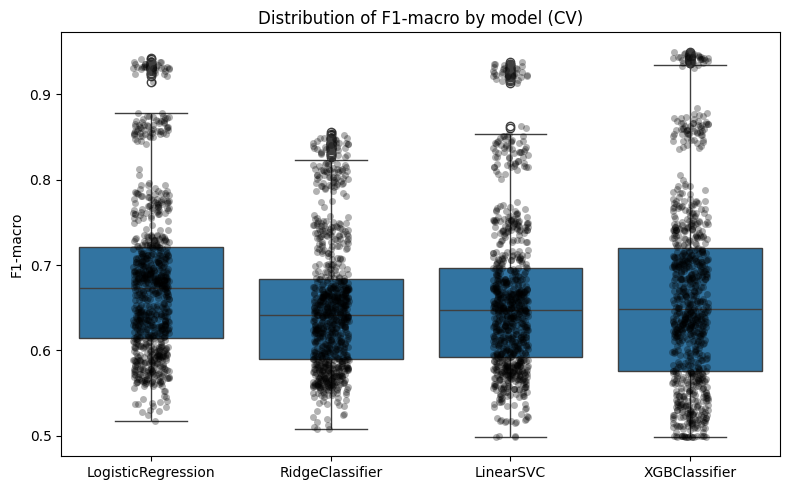

time: 141 ms (started: 2026-02-19 06:24:57 -03:00)


In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_long,
    x="Model",
    y="F1_macro"
)
sns.stripplot(
    data=df_long,
    x="Model",
    y="F1_macro",
    color="black",
    alpha=0.3
)

plt.title("Distribution of F1-macro by model (CV)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()